## Homogeneous BRDF

Estimation using Metropolis-Hastings without gradient

(grayscale / microfacet)

In [1]:
import ivt
from ivt.scene import Scene, DiffuseBRDF, MicrofacetBRDF, Mesh, \
    PerspectiveCamera, HDRFilm, Integrator, EnvironmentLight
from ivt.io import read_image, read_mesh, write_image

In [2]:
import torch

In [3]:
from tqdm import tqdm
import time

In [7]:
scene = Scene()
diffuse = 0.3
specular = 0.3
roughness = 0.3
black = (0,0,0)
scene.set('mat', MicrofacetBRDF(diffuse, specular, roughness))
scene.set('black', DiffuseBRDF(black))
scene.set('mesh1', Mesh.from_file("quad.obj", 'mat')) # surface to reconstruct
scene.set('mesh2', Mesh.from_file("light.obj", 'black', radiance=400)) # area light source
scene.set('film', HDRFilm(256, 256))
scene.set('integrator', Integrator('path', {'max_depth': 3, 'hide_emitters': True}))
scene.set('cam1', PerspectiveCamera.from_lookat(fov=30, origin=(3,3,0), target=(0,0,0), up=(0,1,0))) # camera

In [10]:
renderer = ivt.renderer.Renderer(connector_name='psdr_jit', render_options = {
    "spp": 1,
    "sppe": 0,
    "sppse": 0,
    "npass": 1,
    "log_level": 0
})
# because ivt has a glitch that doesn't allow changing spp, workaround here to render a 128-spp target image
# I_t = renderer(scene)
I_t = torch.cat([renderer(scene) for _ in range(128)]).mean(axis=0).unsqueeze(dim=0)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


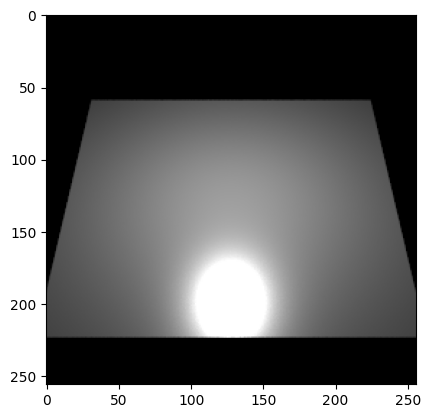

In [11]:
# Visualize the target Image
from matplotlib import pyplot as plt
def showimg(I):
    plt.imshow((I**0.454).detach().cpu().numpy().squeeze(), vmax=1)
def showhist(a):
    plt.hist(a.view(-1).detach().cpu().numpy(), bins=100)
showimg(I_t)

### Loss Function (Likelihood)

Because we're reconstructing the texture for an exact match, we can simply use per-pixel loss in the image space.

In [12]:
def logpdf(img):
    from math import sqrt, pi
    sigma = torch.tensor(0.02)
    # log of density of a normal distribution
    lpdf = ((img - I_t).pow(2.0)/(2.0*sigma.pow(2.0)) + \
                (sqrt(2*pi)*sigma).log()).mean()
    return lpdf

### Posterior Distribution

In [66]:
# To avoid clipping, we are mapping parameters from a finite range (0,1) to (-inf,inf)
def orig_to_norm(x):
    return torch.log(x/(1-x))

def norm_to_orig(y):
    return torch.sigmoid(y)

In [15]:
# potential energy in the parametric space
def U(x):
    scene['mat']['d'] = norm_to_orig(x[0])
    scene['mat']['s'] = norm_to_orig(x[1])
    scene['mat']['r'] = norm_to_orig(x[2])
    img = renderer(scene)
    lpdf = logpdf(img)
    return lpdf, img

### Visualize Posterior Distribution

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [08:22<00:00,  5.03s/it]


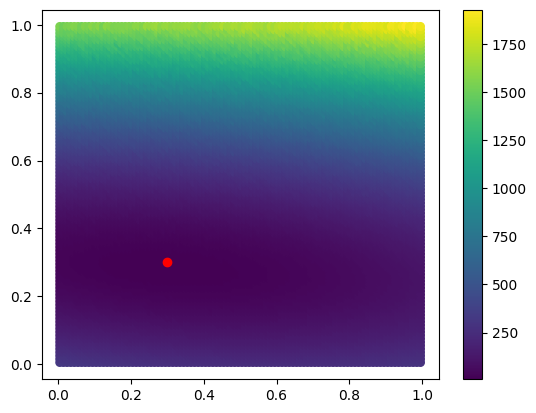

In [46]:
# generate a uniform grid on a slice of the original parametric space (blue=0.2)
# to visualize the posterior distribution
first_components = []
second_components = []
U0 = []
U1 = []
U2 = []
res = 100
for i in tqdm(range(res)):
    for j in range(res):
        x = i/res + 0.5/res
        y = j/res + 0.5/res
        first_components.append(x)
        second_components.append(y)
        U0.append(U(orig_to_norm(torch.tensor([x,y,0.3]).cuda()))[0])
        U1.append(U(orig_to_norm(torch.tensor([x,0.3,y]).cuda()))[0])
        U2.append(U(orig_to_norm(torch.tensor([0.3,x,y]).cuda()))[0])
        

Text(0.5, 0.98, 'Posterior distribution (roughness set to GT=0.3)')

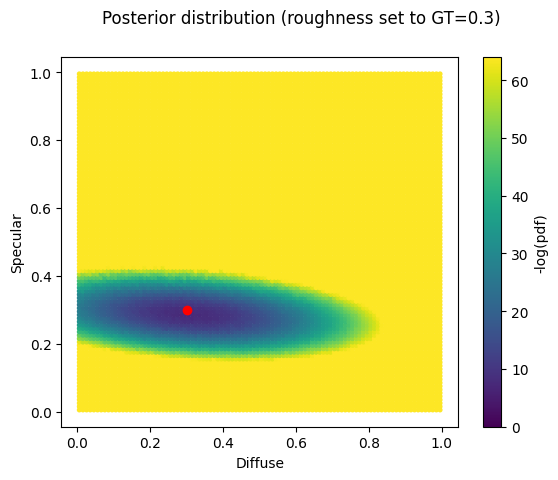

In [65]:
plt.scatter(first_components, second_components, c=[u.cpu() for u in U0], s=7, vmin=0, vmax=64)
cbar = plt.colorbar()
cbar.set_label('-log(pdf)')
plt.xlabel("Diffuse")
plt.ylabel('Specular')
# visualize the ground truth
plt.scatter(0.3, 0.3, color='red')
plt.suptitle('Posterior distribution (roughness set to GT=0.3)')

Text(0.5, 0.98, 'Posterior distribution (specular set to GT=0.3)')

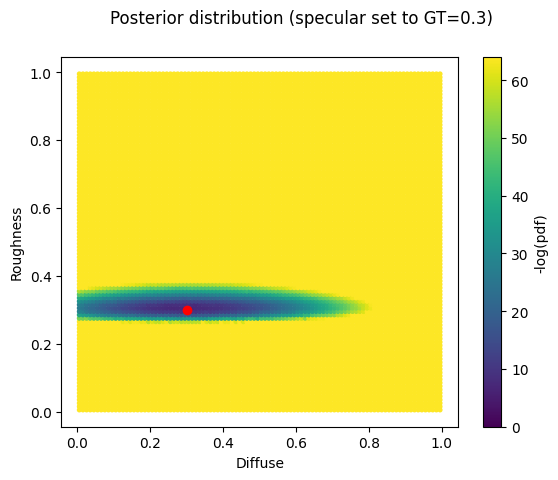

In [64]:
plt.scatter(first_components, second_components, c=[u.cpu() for u in U1], s=7, vmin=0, vmax=64)
cbar = plt.colorbar()
cbar.set_label('-log(pdf)')
plt.xlabel("Diffuse")
plt.ylabel('Roughness')
# visualize the ground truth
plt.scatter(0.3, 0.3, color='red')
plt.suptitle('Posterior distribution (specular set to GT=0.3)')

Text(0.5, 0.98, 'Posterior distribution (diffuse set to GT=0.3)')

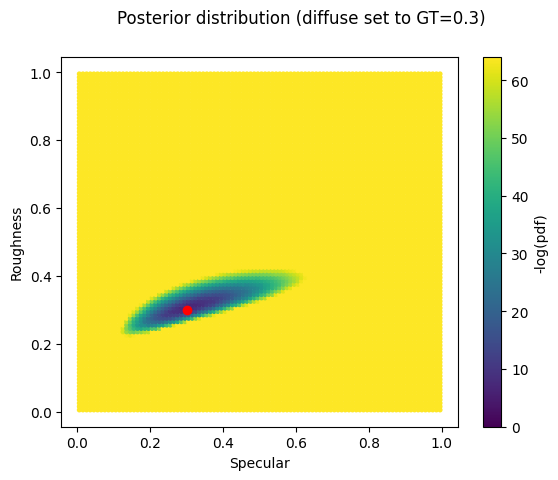

In [63]:
plt.scatter(first_components, second_components, c=[u.cpu() for u in U2], s=7, vmin=0, vmax=64)
cbar = plt.colorbar()
cbar.set_label('-log(pdf)')
plt.xlabel("Specular")
plt.ylabel('Roughness')
# visualize the ground truth
plt.scatter(0.3, 0.3, color='red')
plt.suptitle('Posterior distribution (diffuse set to GT=0.3)')